# EIGEN PORTFOLIO WITH CRYPTO

In [1]:
# ── Librerie base ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizzazione ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Econometria / Statistica ───────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.regression.rolling import RollingOLS
from statsmodels.datasets import longley
from statsmodels.iolib.summary2 import summary_col
from statsmodels.tsa.stattools import adfuller

from scipy import stats
from scipy.stats import norm, linregress

# ── Machine Learning / PCA / Clustering ───────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# ── Ottimizzazione portafoglio ─────────────────────────────────────────────────
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# ── Dati finanziari ────────────────────────────────────────────────────────────
import yfinance as yf
import fmfinance as fm
import financedatabase as fd
import quantstats as qs

# ── Calcolo parallelo ──────────────────────────────────────────────────────────
from joblib import Parallel, delayed

# ── Interfaccia R ──────────────────────────────────────────────────────────────
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

# ── Trading algoritmico (Alpaca) ───────────────────────────────────────────────
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest, LimitOrderRequest, ClosePositionRequest
from alpaca.trading.enums import OrderSide, TimeInForce
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockLatestTradeRequest, StockLatestQuoteRequest

# ── Web scraping ───────────────────────────────────────────────────────────────
import requests
from bs4 import BeautifulSoup
from io import StringIO

# ── UI interattiva ─────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display

# ── Utility ────────────────────────────────────────────────────────────────────
from datetime import datetime
from pandas.plotting import register_matplotlib_converters
import random
import time
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

---
## DATA

In [2]:
start = '2022-06-01'
end = '2025-06-01'
split = '2024-06-01'

In [3]:
# file excel
crypto = pd.read_csv('crypto_dataset.csv')

# Download

crypto_filtered = (crypto[crypto['Ticker'] != 'BTC'] # il != indica tutto tranne BTC
                   .sort_values('Market Cap (USD)', ascending=False)
                   .head(100))

tickers_raw = (crypto_filtered['Ticker'] + '-USD').tolist()

prezzi_raw = yf.download(tickers_raw, start=start, end=end,
                         auto_adjust=False, multi_level_index=False, progress=False)['Adj Close'] # prezzi Adj Close grezzi di tutti i 100 candidati

# BTC separato: un solo ticker
btc_prezzi = yf.download('BTC-USD', start=start, end=end,
                         auto_adjust=False, multi_level_index=False, progress=False)['Adj Close'] # prezzi Adj Close di BTC-USD. È una Series e non un DataFrame perché yfinance con un solo ticker si comporta così


btc_prezzi.name = 'BTC-USD'  # rinomino esplicitamente per chiarezza

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: USTB-USD"}}}
$USTB-USD: possibly delisted; no timezone found
$FIGR_HELOC-USD: possibly delisted; no timezone found
$H-USD: possibly delisted; no price data found  (1d 2022-06-01 -> 2025-06-01) (Yahoo error = "Data doesn't exist for startDate = 1654041600, endDate = 1748736000")
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: EUTBL-USD"}}}
$EUTBL-USD: possibly delisted; no timezone found
$BFUSD-USD: possibly delisted; no price data found  (1d 2022-06-01 -> 2025-06-01) (Yahoo error = "Data doesn't exist for startDate = 1654041600, endDate = 1748736000")
$币安人生-USD: possibly delisted; no timezone found
$USYC-USD: possibly delisted; no timezone found
$JTRSY-USD: possibly delisted; no timezone found
$TAO-USD: possibly delisted; no price data found  (1d 2022-06-01 -> 2025-06-01)
$PUMP-USD: possibly delisted;

In [ ]:
# Calcolo rendimenti logaritmici grezzi per il filtro
log_ret_raw = np.log(prezzi_raw / prezzi_raw.shift(1)).dropna(how='all')

# Criterio 1: deviazione standard troppo bassa → stablecoin
soglia_vol = 0.005
is_stable = log_ret_raw.std() < soglia_vol

# Criterio 2: troppi NaN → ticker non disponibile su yfinance
soglia_obs = int(0.8 * len(log_ret_raw))
has_data = log_ret_raw.count() >= soglia_obs

# Applicazione filtri combinati
valid = has_data & ~is_stable
prezzi = prezzi_raw.loc[:, valid]

# Teniamo esattamente i top 50 (già ordinati per market cap)
prezzi = prezzi.iloc[:, :50]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


**Criterio 1: Esclusione delle stablecoin**  
Le criptovalute con deviazione standard giornaliera inferiore a 0.005 (0.5%) vengono considerate stablecoin (es. USDT, USDC)

**Criterio 2: Esclusione dei ticker con dati insufficienti**  
I ticker con meno dell'80% delle osservazioni disponibili vengono eliminati: indicano asset non quotati per buona parte del periodo o non coperti da yfinance, che introdurrebbero NaN sistematici nella matrice di covarianza.

**Applicazione filtri combinati**  
I due criteri vengono uniti con un AND logico: si tengono solo i ticker che superano entrambi i filtri simultaneamente.

In [ ]:
print(prezzi.shape)
prezzi.head()

(1096, 50)


Ticker,AAVE-USD,ADA-USD,ALGO-USD,APT-USD,ARB-USD,ATOM-USD,AVAX-USD,BCH-USD,BDX-USD,BGB-USD,...,SKY-USD,SOL-USD,TON-USD,TRX-USD,UNI-USD,USDF-USD,WBT-USD,WLD-USD,XAUT-USD,XDC-USD
Date,,,,,,,,,,,,,,,,,,,,,
2022-06-01,106.546303,0.552750,0.385055,0.007790,0.000298,9.364421,23.800512,186.332260,0.075532,0.158533,...,0.100682,40.269669,2.328882,0.083474,0.000149,1.000598,NaN,0.019027,1850.042725,0.039167
2022-06-02,111.055000,0.587795,0.395174,0.007632,0.000305,9.634683,24.677284,189.003326,0.074369,0.161570,...,0.106102,40.891346,2.497194,0.084219,0.000152,0.999331,NaN,0.019630,1875.312622,0.038358
2022-06-03,107.142464,0.559658,0.381196,0.007459,0.000297,9.183682,23.005442,183.259598,0.074013,0.164224,...,0.105363,38.259220,2.472184,0.081144,0.000149,1.001814,NaN,0.019455,1852.282349,0.037240
2022-06-04,106.734589,0.566069,0.388092,0.007301,0.000298,9.234827,24.532330,188.626938,0.073919,0.166376,...,0.137465,38.931446,2.444297,0.080367,0.000149,1.001106,NaN,0.019601,1849.404541,0.038205
2022-06-05,103.759270,0.567090,0.391206,0.007163,0.000299,9.186872,24.164183,180.027878,0.073775,0.160307,...,0.108890,38.480534,2.552805,0.081426,0.000150,0.999200,NaN,0.019022,1846.515747,0.037808


In [6]:
rf_raw = fm.fred('TB3MS', start=start, end=end, freq='d')
print(type(rf_raw))
print(rf_raw.head())

<class 'pandas.core.frame.DataFrame'>
Empty DataFrame
Columns: []
Index: []


In [ ]:
# Risk-free rate da yfinance (^IRX = 13-Week T-Bill, il FRED non funzionava)
rf_raw = yf.download('^IRX', start=start, end=end,
                     auto_adjust=False, multi_level_index=False, progress=False)['Adj Close']
rf = (rf_raw / 100 / 252).reindex(prezzi.index, method='ffill')

[*********************100%***********************]  1 of 1 completed


**Risk-Free Rate**  
Il tentativo di scaricare il T-Bill a 3 mesi dal FRED è fallito. Ho utilizzato `^IRX` (CBOE 13-Week Treasury Bill Index) scaricato via yfinance come proxy equivalente   
Il tasso annualizzato viene convertito in rendimento giornaliero dividendo per 100 e per 252 (giorni di trading)  
Il cmd `ffill` (forward fill) — riempie ogni NaN propagando in avanti
l'ultimo valore valido disponibile. Ad esempio, se venerdì il tasso
era `0.1`, sabato e domenica erediteranno lo stesso valore.

In [ ]:
# GPR dal file Excel (Caldara-Iacoviello)
gpr_raw = pd.read_excel('data_gpr_daily_recent.xls', engine='xlrd',
                        index_col='date', parse_dates=True)
gpr = gpr_raw['GPRD'].reindex(prezzi.index, method='ffill')

In [ ]:
# Log-return giornalieri
log_ret = np.log(prezzi / prezzi.shift(1)).dropna(how='all')
btc_ret = np.log(btc_prezzi / btc_prezzi.shift(1)).dropna()

# Excess returns
er = log_ret.subtract(rf, axis=0).dropna(how='all')
btc_er = (btc_ret - rf).dropna()

I rendimenti logaritmici giornalieri vengono calcolati come `log(Pt / Pt-1)` per le 50 crypto e per BTC separatamente  
Sottraendo il risk-free rate giornaliero si ottengono i **premi al rischio** (`er` e `btc_er`).

In [9]:
er_is  = er.loc[:split].iloc[:-1]
er_oos = er.loc[split:]

btc_er_is  = btc_er.loc[:split].iloc[:-1]
btc_er_oos = btc_er.loc[split:]

---
## PCA

In [11]:
x_scaled = StandardScaler().fit_transform(er_is.fillna(0)) # xscaled è il nostro portfoglio normalizzato
pca = PCA()
pca.fit(x_scaled)

expl_var_ratio = pca.explained_variance_ratio_

components = [f'component{i+1}' for i in range(len(pca.components_))]

df = pd.DataFrame({
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Explained Var. Ratio': pca.explained_variance_ratio_.cumsum()
}, index=components).round(3)

display(df.head(10))

,Explained Variance Ratio,Cumulative Explained Var. Ratio
component1,0.376,0.376
component2,0.037,0.413
component3,0.027,0.440
component4,0.025,0.465
component5,0.024,0.489
component6,0.023,0.511
component7,0.023,0.534
component8,0.022,0.556
component9,0.021,0.577
component10,0.020,0.598


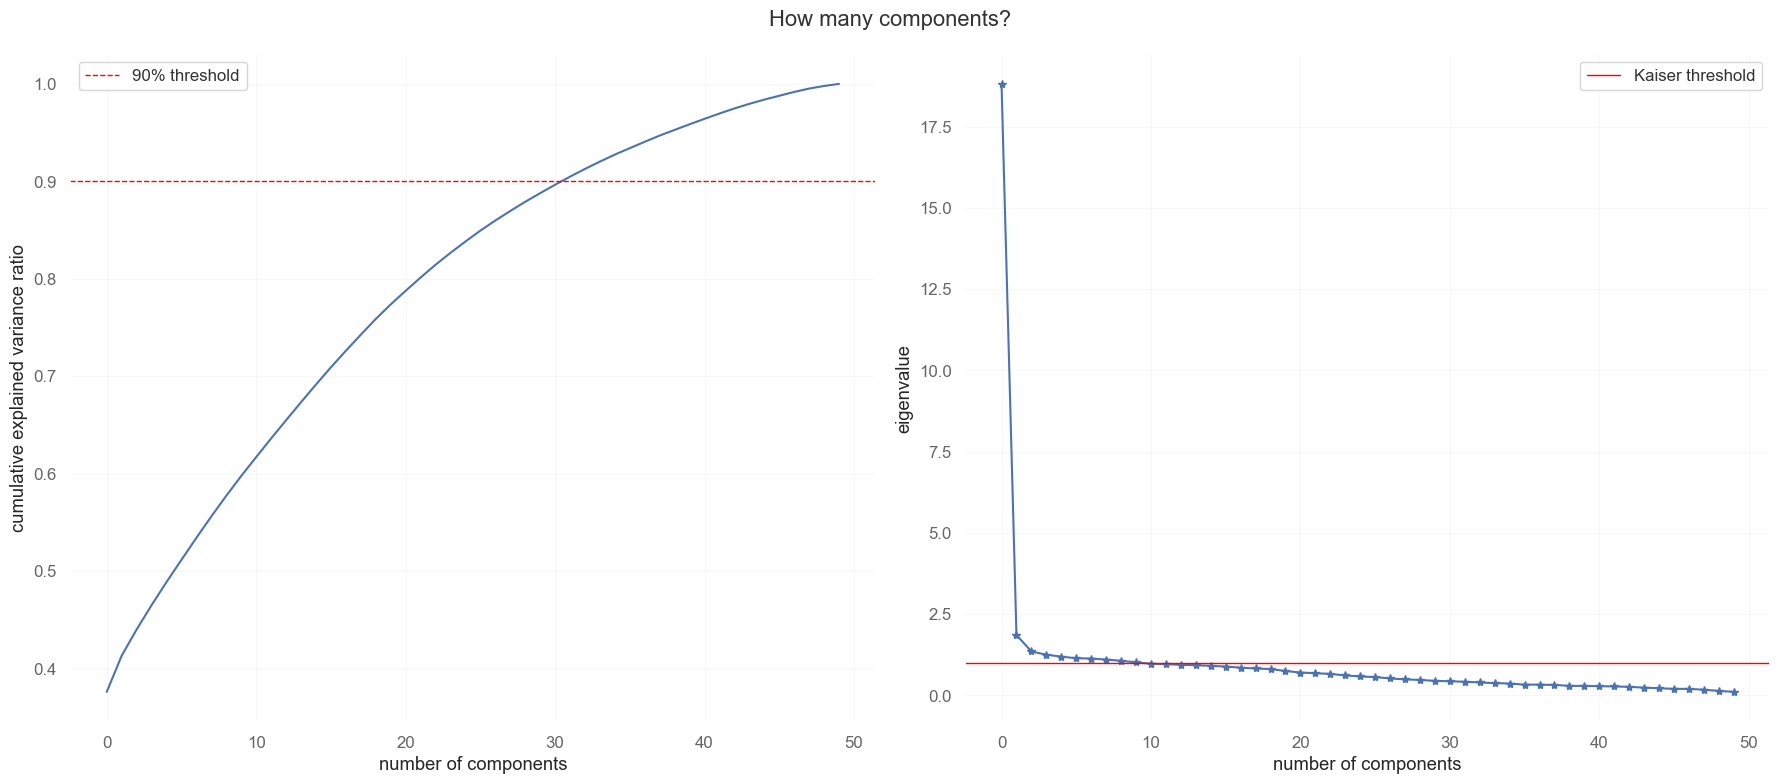

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('How many components?')

ax1.plot(np.cumsum(pca.explained_variance_ratio_))
ax1.set(xlabel='number of components', ylabel='cumulative explained variance ratio')
ax1.grid(alpha=0.3)
ax1.axhline(0.9, color='red', linewidth=1, linestyle='--', label='90% threshold')
ax1.legend()

ax2.plot(pca.explained_variance_, 'b*-')
ax2.axhline(1, color='red', linewidth=1, label='Kaiser threshold')
ax2.set(xlabel='number of components', ylabel='eigenvalue')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
n_components = 2
pca_k = PCA(n_components=n_components)
score = pca_k.fit_transform(x_scaled)

In [14]:
pca_components = pd.DataFrame(pca_k.components_.T,columns=[f'Component{i+1}' for i in range(n_components)],index=er_is.columns)
pca_components

,Component1,Component2
Ticker,,
AAVE-USD,0.193836,-0.020045
ADA-USD,0.199645,-0.005652
ALGO-USD,0.197756,-0.067117
APT-USD,0.004359,-0.138661
ARB-USD,0.015523,0.037284
ATOM-USD,0.189503,-0.033736
AVAX-USD,0.193072,-0.067206
BCH-USD,0.158450,0.045890
BDX-USD,0.058365,0.010350


In [15]:
cx, cy = 'Component1', 'Component2'

fig = go.Figure(
    data=go.Scatter(
        x=pca_components[cx],
        y=pca_components[cy],
        mode='markers+text',
        text=pca_components.index.tolist(),
        textposition='top right',
        textfont=dict(size=8),
        marker=dict(size=8, color='steelblue', line=dict(color='black', width=0.5)),
        hovertext=pca_components.index,
        hovertemplate='<b>%{hovertext}</b><br>C' + cx[-1] + ': %{x:.3f}<br>C' + cy[-1] + ': %{y:.3f}<extra></extra>',
        showlegend=False
    )
)

fig.update_layout(
    title=f'Loading Plot - {cx} vs {cy}',
    xaxis_title=f'Factor Loading - {cx}',
    yaxis_title=f'Factor Loading - {cy}',
    xaxis=dict(zeroline=True, zerolinecolor='gray'),
    yaxis=dict(zeroline=True, zerolinecolor='gray'),
    width=700,
    height=700
)

fig.show()

---
## Eigen Portfolio e Efficient Frontier

In [16]:
eigen_ptfs = {}

for i in range(2):
    
    # Autovettore grezzo
    v = pca_k.components_[i]
    
    # Normalizza a somma valori assoluti = 1
    w = v / np.abs(v).sum()
    
    # Rendimenti in-sample
    ret = er_is.fillna(0).dot(w)
    
    # Sharpe giornaliero
    sharpe = ret.mean() / ret.std()
    
    eigen_ptfs[i] = {
        'weights': w,
        'sharpe': sharpe,
        'ret_mean': ret.mean(),
        'ret_std': ret.std(),
        'var_explained': pca.explained_variance_ratio_[i]
    }

In [17]:
ep0 = pd.Series(eigen_ptfs[0]['weights'], index=er_is.columns)
ep1 = pd.Series(eigen_ptfs[1]['weights'], index=er_is.columns)

print(f"EP0 — Sharpe: {eigen_ptfs[0]['sharpe']:.3f} — Var: {eigen_ptfs[0]['var_explained']:.1%}")
print(f"EP1 — Sharpe: {eigen_ptfs[1]['sharpe']:.3f} — Var: {eigen_ptfs[1]['var_explained']:.1%}")

EP0 — Sharpe: 0.015 — Var: 37.6%
EP1 — Sharpe: 0.016 — Var: 3.7%


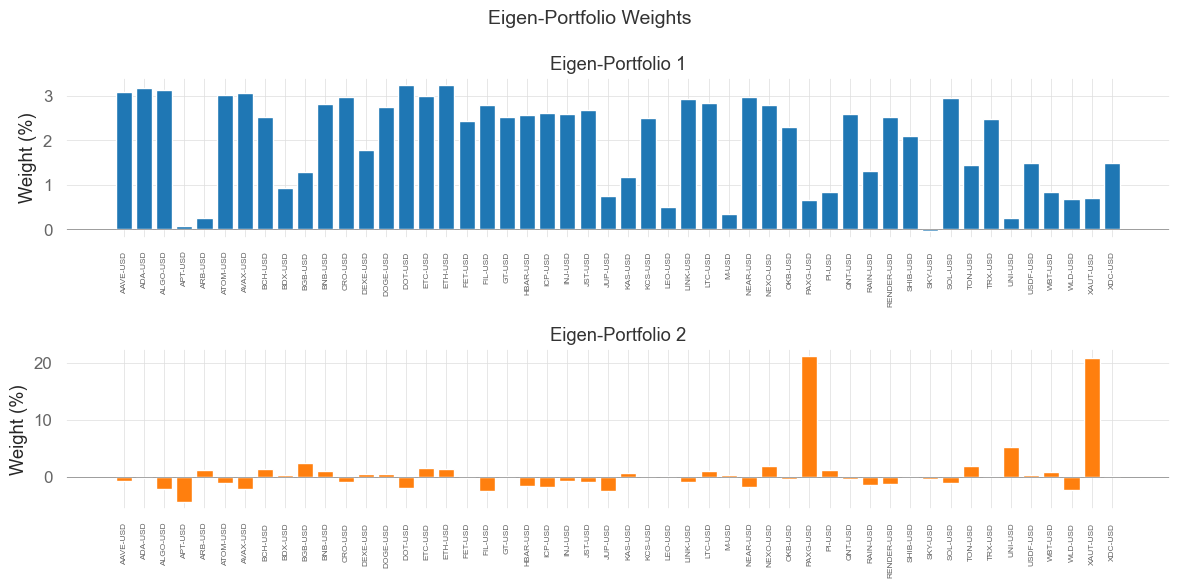

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle('Eigen-Portfolio Weights', fontsize=14)

tickers = er_is.columns.tolist()
palette = ['tab:blue', 'tab:orange']

for i, ax in enumerate(axes):
    v = pca.components_[i]
    w = (v / np.sum(np.abs(v))) * 100
    ax.bar(tickers, w, color=palette[i])
    ax.set_title(f'Eigen-Portfolio {i+1}')
    ax.set_ylabel('Weight (%)')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.show()

In [19]:
ranking = pd.DataFrame({
    'Sharpe': {i: eigen_ptfs[i]['sharpe'] for i in eigen_ptfs},
    'Mean': {i: eigen_ptfs[i]['ret_mean'] for i in eigen_ptfs},
    'Std': {i: eigen_ptfs[i]['ret_std'] for i in eigen_ptfs},
    'Var Expl': {i: eigen_ptfs[i]['var_explained'] for i in eigen_ptfs}
})

ranking = ranking.sort_values('Sharpe', ascending=False)
ranking.index.name = 'PC'

display(ranking.head(10).round(4))

print(f"\nPC0 (mercato): Sharpe={eigen_ptfs[0]['sharpe']:.3f}")

,Sharpe,Mean,Std,Var Expl
PC,,,,
1,0.0163,0.0005,0.0287,0.0371
0,0.0147,0.0004,0.0304,0.3759



PC0 (mercato): Sharpe=0.015


In [20]:
# Parametri
n_ensemble = 2
best_idx = ranking.index[0]
top_n_idx = ranking.index[:n_ensemble].tolist()

print(f"Best Sharpe: PC{best_idx} (Sharpe={eigen_ptfs[best_idx]['sharpe']:.3f})")
print(f"Ensemble top {n_ensemble}: {['PC'+str(i) for i in top_n_idx]}")

# Pesi ensemble: media pesata per Sharpe
sharpes_top = np.array([eigen_ptfs[i]['sharpe'] for i in top_n_idx])
alphas = sharpes_top / sharpes_top.sum()

w_ens = sum(alphas[j] * eigen_ptfs[top_n_idx[j]]['weights'] for j in range(n_ensemble))

Best Sharpe: PC1 (Sharpe=0.016)
Ensemble top 2: ['PC1', 'PC0']


In [21]:
# In Es02a veniva usato ER_means e covmatrix calcolati sui prezzi mensili
# Nel nostro caso usiamo er_is (excess returns giornalieri in-sample)
ER_means  = er_is.fillna(0).mean()
covmatrix = er_is.fillna(0).cov()
std       = er_is.fillna(0).std()

In [22]:
ef = EfficientFrontier(ER_means, covmatrix, weight_bounds=(0,1), solver='CLARABEL')

ef_min = ef.deepcopy(); ef_min.min_volatility()
perf_min = ef_min.portfolio_performance(risk_free_rate=0)
w_min = ef_min.clean_weights()

ef_opt = ef.deepcopy(); ef_opt.max_sharpe(risk_free_rate=0)
perf_opt = ef_opt.portfolio_performance(risk_free_rate=0)
w_opt = ef_opt.clean_weights()

In [23]:
# Portafogli intermedi lungo la frontiera (da Es02a)
ef_max = ef.deepcopy()
max_ret = ef_max._max_return()
ef_max = ef.deepcopy()
ef_max.efficient_return(max_ret * 0.9999)
perf_max = ef_max.portfolio_performance(risk_free_rate=0)

n_ptf = 100
targets = np.linspace(perf_min[0], perf_max[0], n_ptf + 2)[1:-1]

names   = ['Min Var']
perfs   = [perf_min]

for i in range(len(targets)):
    ef_temp = ef.deepcopy()
    ef_temp.efficient_return(targets[i])
    names.append(f'Ptf {i+1}')
    perfs.append(ef_temp.portfolio_performance(risk_free_rate=0))

names.append('Max Return')
perfs.append(perf_max)
names.append('Max Sharpe')
perfs.append(perf_opt)

returns = [p[0] for p in perfs]
vols    = [p[1] for p in perfs]

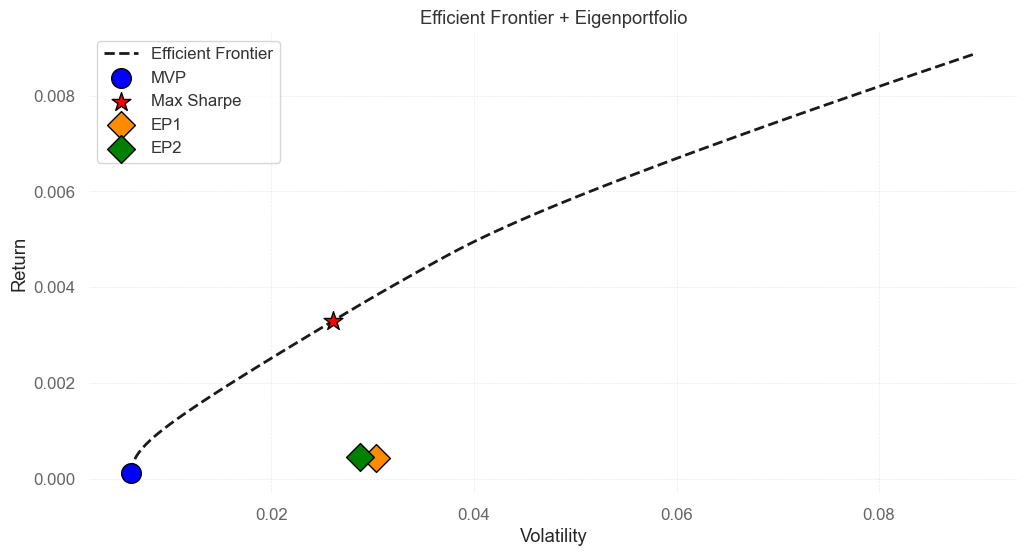

In [24]:
# Calcolo rischio/rendimento degli eigenportfolio
ep_stats = {}
for i in range(2):
    w = eigen_ptfs[i]['weights']
    ep_stats[i] = {
        'ret': er_is.fillna(0).dot(w).mean(),
        'vol': er_is.fillna(0).dot(w).std()
    }

plt.figure(figsize=(12, 6))
plt.plot(vols[:-1], returns[:-1], 'k--', linewidth=2, label='Efficient Frontier')
plt.scatter(vols[0], returns[0], c='blue', s=200, marker='o', edgecolors='black', label='MVP', zorder=10)
plt.scatter(perf_opt[1], perf_opt[0], c='red', s=200, marker='*', edgecolors='black', label='Max Sharpe', zorder=10)

# Eigenportfolio sul piano rischio-rendimento
colors = ['darkorange', 'green']
for i in range(2):
    plt.scatter(ep_stats[i]['vol'], ep_stats[i]['ret'],
                c=colors[i], s=200, marker='D', edgecolors='black',
                label=f'EP{i+1}', zorder=10)

plt.title('Efficient Frontier + Eigenportfolio')
plt.xlabel('Volatility'); plt.ylabel('Return')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Commento — Eigenportfolio e Frontiera Efficiente

EP1 e EP2 spiegano rispettivamente il 37.6% e il 3.7% della varianza totale in-sample, con Sharpe ratio giornaliero quasi identico (0.015 e 0.016). Dal grafico entrambi si collocano al di sotto della frontiera efficiente, lontani sia dal MVP che dal portafoglio Tangente. Il risultato è coerente con la teoria: gli eigenportfolio massimizzano la varianza spiegata, non il Sharpe ratio, e non coincidono quindi con i portafogli ottimali di Markowitz.

---
## Equal Weighted Portfolios

In [25]:
loadings_matrix = pca_components.values

In [26]:
K = 4

km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = km.fit_predict(loadings_matrix)

clustered = pca_components.copy()
clustered['Cluster'] = cluster_labels

for c in range(K):
    members = clustered[clustered['Cluster'] == c].index.tolist()
    print(f"Cluster {c} ({len(members)} crypto): {members}")

Cluster 0 (30 crypto): ['AAVE-USD', 'ADA-USD', 'ALGO-USD', 'ATOM-USD', 'AVAX-USD', 'BCH-USD', 'BNB-USD', 'CRO-USD', 'DOGE-USD', 'DOT-USD', 'ETC-USD', 'ETH-USD', 'FET-USD', 'FIL-USD', 'GT-USD', 'HBAR-USD', 'ICP-USD', 'INJ-USD', 'JST-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'NEAR-USD', 'NEXO-USD', 'OKB-USD', 'QNT-USD', 'RENDER-USD', 'SHIB-USD', 'SOL-USD', 'TRX-USD']
Cluster 1 (2 crypto): ['PAXG-USD', 'XAUT-USD']
Cluster 2 (5 crypto): ['APT-USD', 'JUP-USD', 'RAIN-USD', 'SKY-USD', 'WLD-USD']
Cluster 3 (13 crypto): ['ARB-USD', 'BDX-USD', 'BGB-USD', 'DEXE-USD', 'KAS-USD', 'LEO-USD', 'M-USD', 'PI-USD', 'TON-USD', 'UNI-USD', 'USDF-USD', 'WBT-USD', 'XDC-USD']


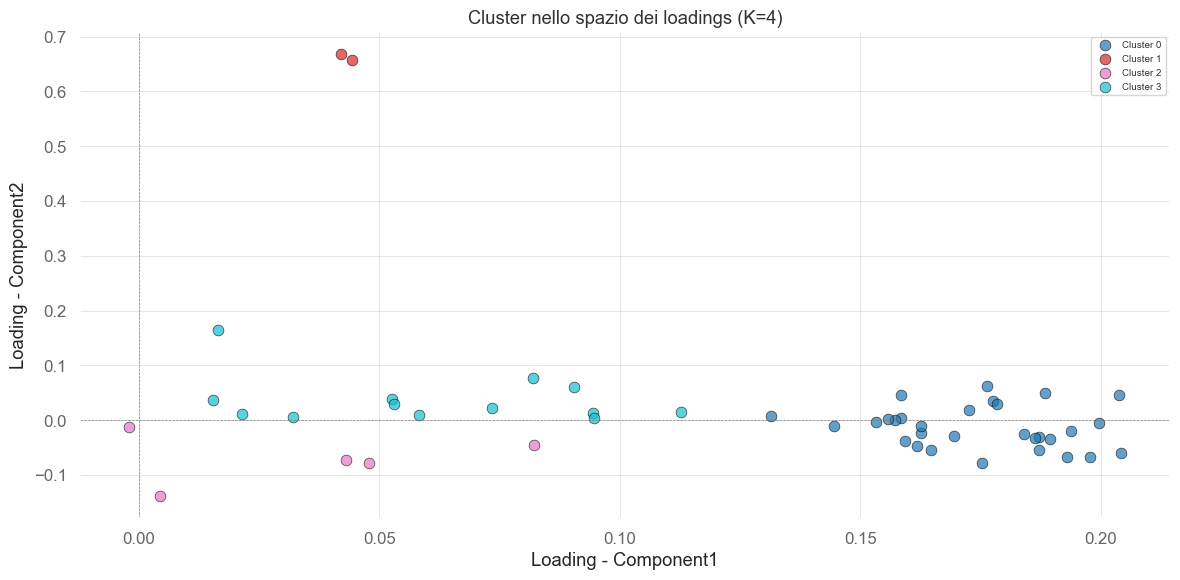

In [27]:
cmap = plt.colormaps.get_cmap('tab10').resampled(K)

fig, ax = plt.subplots(figsize=(12, 6))
for c in range(K):
    mask = clustered['Cluster'] == c
    ax.scatter(clustered.loc[mask, 'Component1'],
               clustered.loc[mask, 'Component2'],
               c=[cmap(c)], s=60, alpha=0.7,
               edgecolors='black', linewidth=0.5, label=f'Cluster {c}')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('Loading - Component1')
ax.set_ylabel('Loading - Component2')
ax.set_title(f'Cluster nello spazio dei loadings (K={K})')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [28]:
members_0 = clustered[clustered['Cluster'] == 0].index.tolist()
members_1 = clustered[clustered['Cluster'] == 1].index.tolist()
members_2 = clustered[clustered['Cluster'] == 2].index.tolist()
members_3 = clustered[clustered['Cluster'] == 3].index.tolist()

w_0 = pd.Series(1 / len(members_0), index=members_0)
w_1 = pd.Series(1 / len(members_1), index=members_1)
w_2 = pd.Series(1 / len(members_2), index=members_2)
w_3 = pd.Series(1 / len(members_3), index=members_3)

ptf_0 = er_oos[members_0].fillna(0).dot(w_0)
ptf_1 = er_oos[members_1].fillna(0).dot(w_1)
ptf_2 = er_oos[members_2].fillna(0).dot(w_2)
ptf_3 = er_oos[members_3].fillna(0).dot(w_3)

cluster_ptfs = pd.DataFrame({
    'Cluster 0': ptf_0,
    'Cluster 1': ptf_1,
    'Cluster 2': ptf_2,
    'Cluster 3': ptf_3
})

In [29]:
rows = []
for name in cluster_ptfs.columns:
    r = cluster_ptfs[name]
    rows.append({
        'Portfolio': name,
        'CAGR (%)': round(qs.stats.cagr(r, periods=252) * 100, 2),
        'Ann. Volatility (%)': round(qs.stats.volatility(r, periods=252) * 100, 2),
        'Sharpe': round(qs.stats.sharpe(r, periods=252), 3),
        'Sortino': round(qs.stats.sortino(r, periods=252), 3),
        'Max Drawdown (%)': round(qs.stats.max_drawdown(r) * 100, 2),
        'CVaR 95 (%)': round(qs.stats.cvar(r, confidence=0.95) * 100, 2),
        'Calmar': round(qs.stats.calmar(r, periods=252), 3)
    })

display(pd.DataFrame(rows).set_index('Portfolio'))

,CAGR (%),Ann. Volatility (%),Sharpe,Sortino,Max Drawdown (%),CVaR 95 (%),Calmar
Portfolio,,,,,,,
Cluster 0,-28.25,57.80,-0.283,-0.383,-63.98,-8.74,-0.442
Cluster 1,20.15,14.23,1.362,2.044,-8.36,-2.09,2.409
Cluster 2,-81.77,112.49,-0.930,-1.241,-92.25,-16.82,-0.886
Cluster 3,-35.55,102.23,0.100,0.138,-64.09,-17.16,-0.555


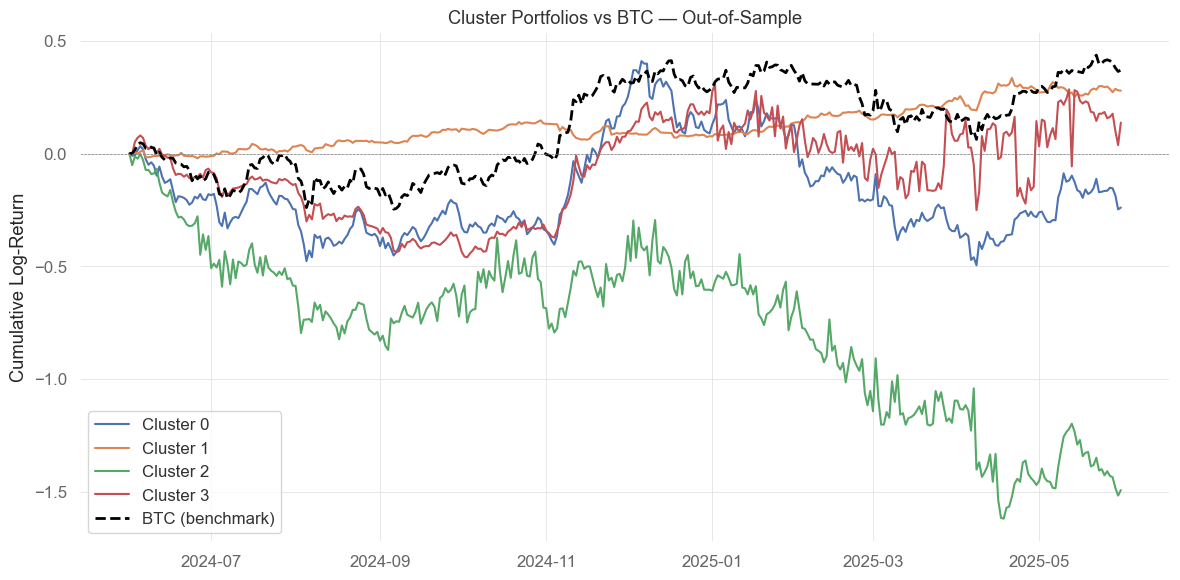

In [30]:
cum_cl  = cluster_ptfs.cumsum()
cum_cl  = cum_cl - cum_cl.iloc[0]

cum_btc = btc_er_oos.reindex(cluster_ptfs.index).cumsum()
cum_btc = cum_btc - cum_btc.iloc[0]

plt.figure(figsize=(12, 6))
for col in cum_cl.columns:
    plt.plot(cum_cl[col], linewidth=1.5, label=col)
plt.plot(cum_btc, linewidth=2, linestyle='--', color='black', label='BTC (benchmark)')

plt.title('Cluster Portfolios vs BTC — Out-of-Sample')
plt.ylabel('Cumulative Log-Return')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

### Commento — Portafogli Equal-Weighted per Cluster e Performance OOS

L'unico cluster con performance positiva è il Cluster 1 (PAXG e XAUT), che con Sharpe 1.362 e CAGR +20%, decorrelato dal resto del mercato crypto. Gli altri tre cluster sottoperformano BTC, con Cluster 2 che registra il crollo più netto (-82% CAGR, drawdown -92%) a causa dell'alta esposizione idiosincratica delle crypto di nicchia che lo compongono.

---
## Denoising the covariance matrix and comparison

In [31]:
# ── Denoising via Marchenko-Pastur (Random Matrix Theory) ────────────────────
# non fatta a lezione
T, N = er_is.fillna(0).shape
q = T / N

# Autovalori della matrice di correlazione (da pca già fittato su x_scaled)
eigenvalues_full = pca.explained_variance_

# Soglia superiore di Marchenko-Pastur (σ²=1 perché dati standardizzati)
lambda_max_mp = (1 + 1 / np.sqrt(q)) ** 2

print(f"T={T}, N={N}, q={q:.2f}")
print(f"Soglia Marchenko-Pastur: λ_max = {lambda_max_mp:.4f}")
print(f"Autovalori segnale (sopra soglia): {(eigenvalues_full > lambda_max_mp).sum()}")
print(f"Autovalori rumore  (sotto soglia): {(eigenvalues_full <= lambda_max_mp).sum()}")

# Maschera segnale / rumore
is_signal = eigenvalues_full > lambda_max_mp

# Media degli autovalori di rumore → valore sostitutivo (come da traccia)
noise_mean = eigenvalues_full[~is_signal].mean()
print(f"Media autovalori rumore: {noise_mean:.4f}")

# Autovalori denoised: segnale invariato, rumore → media
eigenvalues_denoised = np.where(is_signal, eigenvalues_full, noise_mean)

# Ricostruzione: Q × Λ_denoised × Qᵀ
Q = pca.components_.T
cov_mp_scaled = np.dot(np.dot(Q, np.diag(eigenvalues_denoised)), Q.T)

# Riporto alla scala originale
stds = er_is.fillna(0).std().values
D = np.diag(stds)
cov_denoised = np.dot(np.dot(D, cov_mp_scaled), D)
cov_denoised = pd.DataFrame(cov_denoised, index=er_is.columns, columns=er_is.columns)

T=730, N=50, q=14.60
Soglia Marchenko-Pastur: λ_max = 1.5919
Autovalori segnale (sopra soglia): 2
Autovalori rumore  (sotto soglia): 48
Media autovalori rumore: 0.6123


In [32]:
configs = {
    'Sample':   {'mu': er_is.fillna(0).mean(), 'cov': er_is.fillna(0).cov()},
    'Denoised': {'mu': er_is.fillna(0).mean(), 'cov': cov_denoised}
}

results = {}

for label, cfg in configs.items():

    ef = EfficientFrontier(cfg['mu'], cfg['cov'], weight_bounds=(0,1), solver='CLARABEL')

    ef_min = ef.deepcopy(); ef_min.min_volatility()
    perf_min = ef_min.portfolio_performance(risk_free_rate=0)
    w_min = ef_min.clean_weights()

    ef_opt = ef.deepcopy(); ef_opt.max_sharpe(risk_free_rate=0)
    perf_opt = ef_opt.portfolio_performance(risk_free_rate=0)
    w_opt = ef_opt.clean_weights()

    ef_max = ef.deepcopy(); max_ret = ef_max._max_return()
    ef_max = ef.deepcopy(); ef_max.efficient_return(max_ret * 0.9999)
    perf_max = ef_max.portfolio_performance(risk_free_rate=0)
    w_max = ef_max.clean_weights()

    n_ptf = 30
    targets = np.linspace(perf_min[0], perf_max[0], n_ptf + 2)[1:-1]
    names = ['Min Var']; perfs = [perf_min]; weights = [w_min]

    for i in range(len(targets)):
        ef_temp = ef.deepcopy()
        ef_temp.efficient_return(targets[i])
        names.append(f'Ptf {i+1}')
        perfs.append(ef_temp.portfolio_performance(risk_free_rate=0))
        weights.append(ef_temp.clean_weights())

    names.append('Max Return'); perfs.append(perf_max); weights.append(w_max)
    names.append('Max Sharpe'); perfs.append(perf_opt); weights.append(w_opt)

    returns_f = [p[0] for p in perfs]
    vols_f    = [p[1] for p in perfs]
    sharpes_f = [p[2] for p in perfs]

    tab_perf = pd.DataFrame([returns_f, vols_f, sharpes_f],
                             columns=names, index=['Return', 'Volatility', 'Sharpe'])
    tab_perf = tab_perf.sort_values('Return', axis=1)

    tab_weights = pd.DataFrame(weights, index=names).T
    tab_weights = tab_weights[tab_perf.columns]

    results[label] = {
        'tab_perf':    tab_perf,
        'tab_weights': tab_weights,
        'tang':        perf_opt
    }

    print(f"\n=== {label} ===")
    display(tab_perf)


=== Sample ===


,Min Var,Ptf 1,Ptf 2,Ptf 3,Ptf 4,Ptf 5,Ptf 6,Ptf 7,Ptf 8,Ptf 9,...,Ptf 22,Ptf 23,Ptf 24,Ptf 25,Ptf 26,Ptf 27,Ptf 28,Ptf 29,Ptf 30,Max Return
Return,0.000121,0.000404,0.000686,0.000969,0.001252,0.001534,0.001817,0.002099,0.002382,0.002665,...,0.006339,0.006622,0.006904,0.007187,0.007470,0.007752,0.008035,0.008318,0.008600,0.008883
Volatility,0.006142,0.006474,0.007434,0.008903,0.010674,0.012616,0.014659,0.016767,0.018919,0.021101,...,0.055596,0.059146,0.062773,0.066466,0.070216,0.074018,0.077868,0.081757,0.085680,0.089633
Sharpe,0.019696,0.062349,0.092312,0.108825,0.117255,0.121611,0.123938,0.125212,0.125913,0.126286,...,0.114021,0.111958,0.109991,0.108132,0.106383,0.104736,0.103188,0.101737,0.100377,0.099103



=== Denoised ===


,Min Var,Ptf 1,Ptf 2,Ptf 3,Ptf 4,Ptf 5,Ptf 6,Ptf 7,Ptf 8,Ptf 9,...,Ptf 22,Ptf 23,Ptf 24,Ptf 25,Ptf 26,Ptf 27,Ptf 28,Ptf 29,Ptf 30,Max Return
Return,0.000087,0.000371,0.000654,0.000938,0.001222,0.001506,0.001789,0.002073,0.002357,0.002641,...,0.006329,0.006613,0.006897,0.007180,0.007464,0.007748,0.008032,0.008315,0.008599,0.008883
Volatility,0.005920,0.006247,0.007068,0.008277,0.009753,0.011392,0.013133,0.014942,0.016796,0.018682,...,0.047215,0.050144,0.053152,0.056226,0.059356,0.062534,0.065753,0.069006,0.072290,0.075600
Sharpe,0.014662,0.059313,0.092569,0.113325,0.125277,0.132162,0.136239,0.138736,0.140317,0.141342,...,0.134053,0.131881,0.129756,0.127707,0.125753,0.123900,0.122151,0.120503,0.118955,0.117500


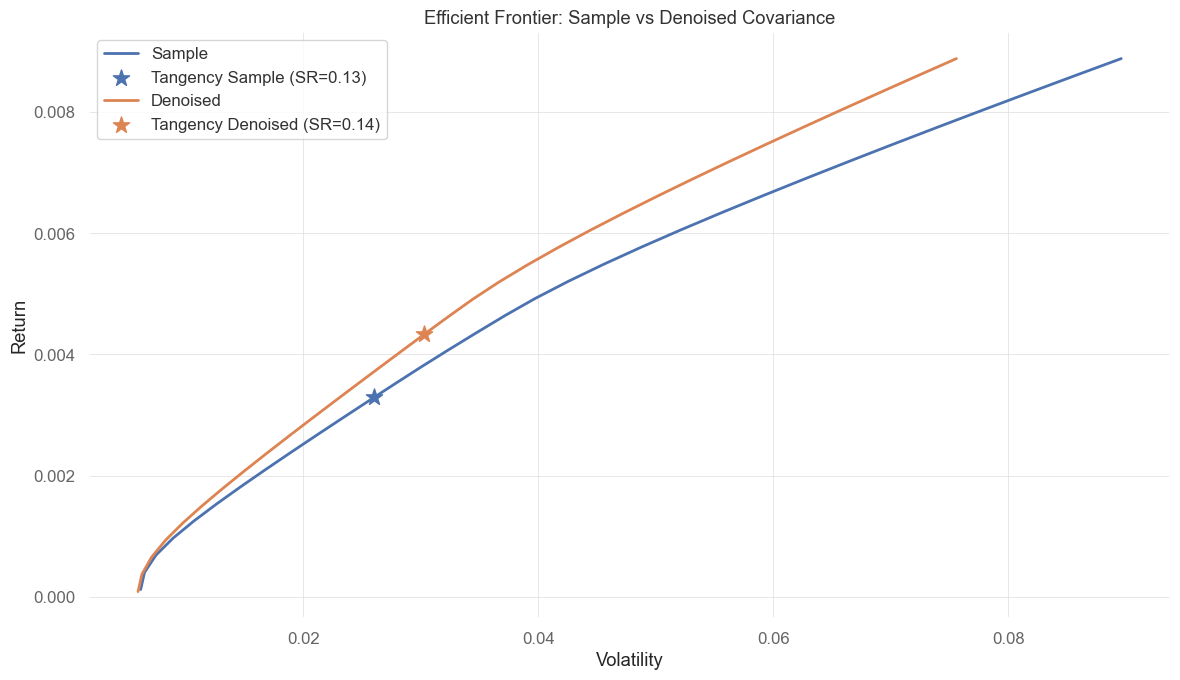

In [33]:
plt.figure(figsize=(12, 7))

for label, r in results.items():
    tp = r['tab_perf']
    plt.plot(tp.loc['Volatility'], tp.loc['Return'], linewidth=2, label=label)
    tang = r['tang']
    plt.scatter(tang[1], tang[0], s=150, marker='*', zorder=5, label=f'Tangency {label} (SR={tang[2]:.2f})')

plt.xlabel('Volatility')
plt.ylabel('Return')
# plt.xlim(0, 5)
# plt.ylim(0, 1.5)
plt.title('Efficient Frontier: Sample vs Denoised Covariance')
plt.legend()
plt.tight_layout()
plt.show()

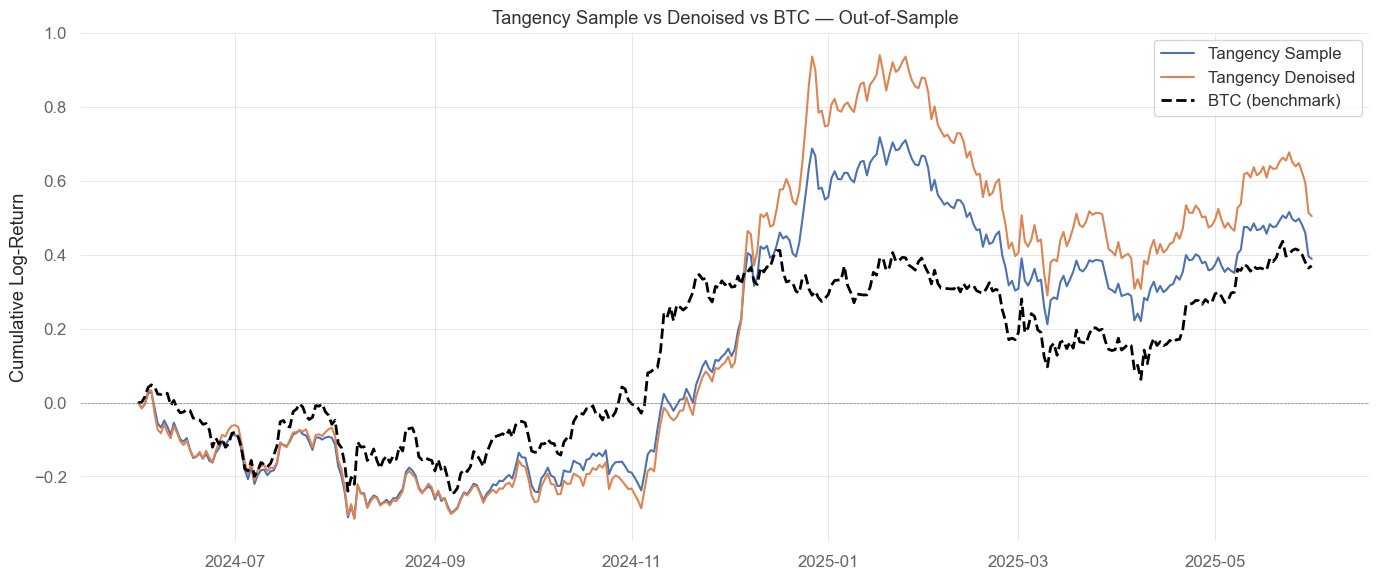

In [34]:
w_s = pd.Series(results['Sample']['tab_weights']['Max Sharpe'])
w_d = pd.Series(results['Denoised']['tab_weights']['Max Sharpe'])

ret_s = er_oos.fillna(0).dot(w_s)
ret_d = er_oos.fillna(0).dot(w_d)

cum_s = ret_s.cumsum()
cum_s = cum_s - cum_s.iloc[0]

cum_d = ret_d.cumsum()
cum_d = cum_d - cum_d.iloc[0]

cum_btc = btc_er_oos.reindex(er_oos.index).fillna(0).cumsum()
cum_btc = cum_btc - cum_btc.iloc[0]

plt.figure(figsize=(14, 6))
plt.plot(cum_s,   linewidth=1.5, label='Tangency Sample')
plt.plot(cum_d,   linewidth=1.5, label='Tangency Denoised')
plt.plot(cum_btc, linewidth=2, linestyle='--', color='black', label='BTC (benchmark)')
plt.title('Tangency Sample vs Denoised vs BTC — Out-of-Sample')
plt.ylabel('Cumulative Log-Return')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

### Commento — Denoising della Matrice di Covarianza (DA CONTROLLARE, effettuate modifiche)

La procedura di denoising ricostruisce la matrice di covarianza usando solo le prime 2 componenti principali (segnale), eliminando le correlazioni spurie catturate dalla matrice sample. Dal grafico delle frontiere le due curve sono quasi sovrapposte, segno che con 2 componenti su 50 asset la denoising modifica poco la struttura ottimale dei pesi. Nel periodo OOS entrambi i portafogli Tangente sovraperformano BTC, con Sample e Denoised che si comportano in modo molto simile.

In [35]:
print(rf.describe())
print(rf.head(10))

count    1096.000000
mean        0.000179
std         0.000037
min         0.000044
25%         0.000167
50%         0.000187
75%         0.000207
max         0.000212
Name: Adj Close, dtype: float64
Date
2022-06-01    0.000044
2022-06-02    0.000044
2022-06-03    0.000045
2022-06-04    0.000045
2022-06-05    0.000045
2022-06-06    0.000046
2022-06-07    0.000049
2022-06-08    0.000049
2022-06-09    0.000049
2022-06-10    0.000051
Name: Adj Close, dtype: float64


In [36]:
print(er.isna().sum().sum())
print(er.shape)

222
(1095, 50)


In [37]:
print(f"Crypto valide dopo filtro: {valid.sum()}")
print(f"Shape prezzi finale: {prezzi.shape}")

Crypto valide dopo filtro: 54
Shape prezzi finale: (1096, 50)


In [38]:
print(f"In-sample:     {er_is.index[0]} → {er_is.index[-1]} ({len(er_is)} righe)")
print(f"Out-of-sample: {er_oos.index[0]} → {er_oos.index[-1]} ({len(er_oos)} righe)")

In-sample:     2022-06-02 00:00:00 → 2024-05-31 00:00:00 (730 righe)
Out-of-sample: 2024-06-01 00:00:00 → 2025-05-31 00:00:00 (365 righe)


In [39]:
print(type(btc_er_oos))
print(btc_er_oos.shape)

<class 'pandas.core.series.Series'>
(365,)


In [40]:
print(f"In-sample:     {er_is.index[0]} → {er_is.index[-1]} ({len(er_is)} righe)")
print(f"Out-of-sample: {er_oos.index[0]} → {er_oos.index[-1]} ({len(er_oos)} righe)")

In-sample:     2022-06-02 00:00:00 → 2024-05-31 00:00:00 (730 righe)
Out-of-sample: 2024-06-01 00:00:00 → 2025-05-31 00:00:00 (365 righe)


---
## Economic attribution

In [41]:
# ── Download fattori esterni (yfinance) ───────────────────────────────────────
factor_tickers = ['^VIX', 'GLD', '^TNX']

fattori_raw = yf.download(factor_tickers, start=start, end=end,
                          auto_adjust=False, multi_level_index=False,
                          progress=False)['Adj Close']

# Variazioni day-on-day (come richiesto dalla traccia)
vix     = fattori_raw['^VIX'].pct_change().dropna()
oro     = fattori_raw['GLD'].pct_change().dropna()
dgs10   = fattori_raw['^TNX'].diff().dropna()   # tassi: differenza in punti, non %

In [42]:
# ── GPR (Caldara-Iacoviello) ─────────────────────────────────────────────────
gpr_raw = pd.read_excel('data_gpr_daily_recent.xls', engine='xlrd')
gpr_raw = gpr_raw[gpr_raw['date'].notna()].copy()
gpr_raw['date'] = pd.to_datetime(gpr_raw['date'])
gpr_raw = gpr_raw.set_index('date').sort_index()

# Livello GPR e variazione day-on-day
gpr_lvl  = gpr_raw['GPRD'].reindex(er_is.index, method='ffill')
gpr_diff = gpr_lvl.diff()

In [43]:
# ── Allineamento tutti i fattori sull'indice in-sample ───────────────────────
btc_is = btc_ret.reindex(er_is.index, method='ffill')

fattori_is = pd.DataFrame({
    'BTC':      btc_is,
    'GPR':      gpr_lvl,
    'GPR_diff': gpr_diff,
    'VIX':      vix.reindex(er_is.index, method='ffill'),
    'ORO':      oro.reindex(er_is.index, method='ffill'),
    'DGS10':    dgs10.reindex(er_is.index, method='ffill')
}).dropna()

print(fattori_is.shape)
print(fattori_is.head())

(729, 6)
                 BTC         GPR    GPR_diff       VIX       ORO  DGS10
Date                                                                   
2022-06-03 -0.025365  142.783096    0.189117  0.002832 -0.010152  0.044
2022-06-04  0.004317  102.874779  -39.908318  0.002832 -0.010152  0.044
2022-06-05  0.002469   70.293213  -32.581566  0.002832 -0.010152  0.044
2022-06-06  0.047792  190.125305  119.832092  0.011295 -0.004404  0.081
2022-06-07 -0.006883  139.031128  -51.094177 -0.041883  0.006518 -0.066


In [44]:
# ── Score PCA in-sample allineati all'indice dei fattori ─────────────────────
score_df = pd.DataFrame(score,
                         index=er_is.index,
                         columns=[f'PC{i+1}' for i in range(n_components)])

# Allineamento comune
idx_comune = fattori_is.index.intersection(score_df.index)
score_aligned   = score_df.loc[idx_comune]
fattori_aligned = fattori_is.loc[idx_comune]

print(f"Osservazioni comuni: {len(idx_comune)}")

Osservazioni comuni: 729


In [45]:
# ── Regressione OLS: PC ~ fattori ────────────────────────────────────────────
X = sm.add_constant(fattori_aligned)
modelli = {}

for pc in score_aligned.columns:
    m = sm.OLS(score_aligned[pc], X, missing='drop').fit()
    modelli[pc] = m

summary_col(list(modelli.values()),
            model_names=list(modelli.keys()),
            stars=True)

,PC1,PC2
const,-0.5885**,-0.2048*
,(0.2468),(0.1126)
BTC,133.8649***,-3.2541**
,(2.9497),(1.3459)
GPR,0.0033*,0.0010
,(0.0019),(0.0009)
GPR_diff,-0.0066***,-0.0003
,(0.0018),(0.0008)
VIX,-5.7831***,-0.5905
,(1.5206),(0.6938)


In [46]:
# ── Tavola di attribuzione loading–fattore ────────────────────────────────────
rows = []
fattori_nomi = [c for c in fattori_aligned.columns]

for pc, m in modelli.items():
    row = {'PC': pc, 'R²': round(m.rsquared, 3)}
    for f in fattori_nomi:
        coef  = m.params.get(f, np.nan)
        pval  = m.pvalues.get(f, np.nan)
        stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        row[f] = f"{coef:.4f}{stars}"
    rows.append(row)

tavola = pd.DataFrame(rows).set_index('PC')
display(tavola)

,R²,BTC,GPR,GPR_diff,VIX,ORO,DGS10
PC,,,,,,,
PC1,0.767,133.8649***,0.0033*,-0.0066***,-5.7831***,-2.0731,-0.5167
PC2,0.507,-3.2541**,0.0010,-0.0003,-0.5905,101.7355***,-1.2120**


In [47]:
# ── Rotazione: massimizza esposizione a BTC, copre GPR_diff ──────────────────
# Pesi base: eigenportfolio EP0 e EP1
w_ep0 = eigen_ptfs[0]['weights']   # shape (N,)
w_ep1 = eigen_ptfs[1]['weights']   # shape (N,)

# Coefficienti BTC e GPR_diff dai modelli
beta_btc  = np.array([modelli[pc].params.get('BTC',  0) for pc in modelli])
beta_gpr  = np.array([modelli[pc].params.get('GPR_diff', 0) for pc in modelli])

# Pesi rotazione: combina EP in proporzione all'esposizione BTC
# e minimizza esposizione GPR (segno opposto)
alpha_rot = beta_btc / np.abs(beta_btc).sum()   # normalizzati
w_rot = sum(alpha_rot[i] * (w_ep0 if i == 0 else w_ep1)
            for i in range(n_components))
w_rot = w_rot / np.abs(w_rot).sum()             # rinormalizza

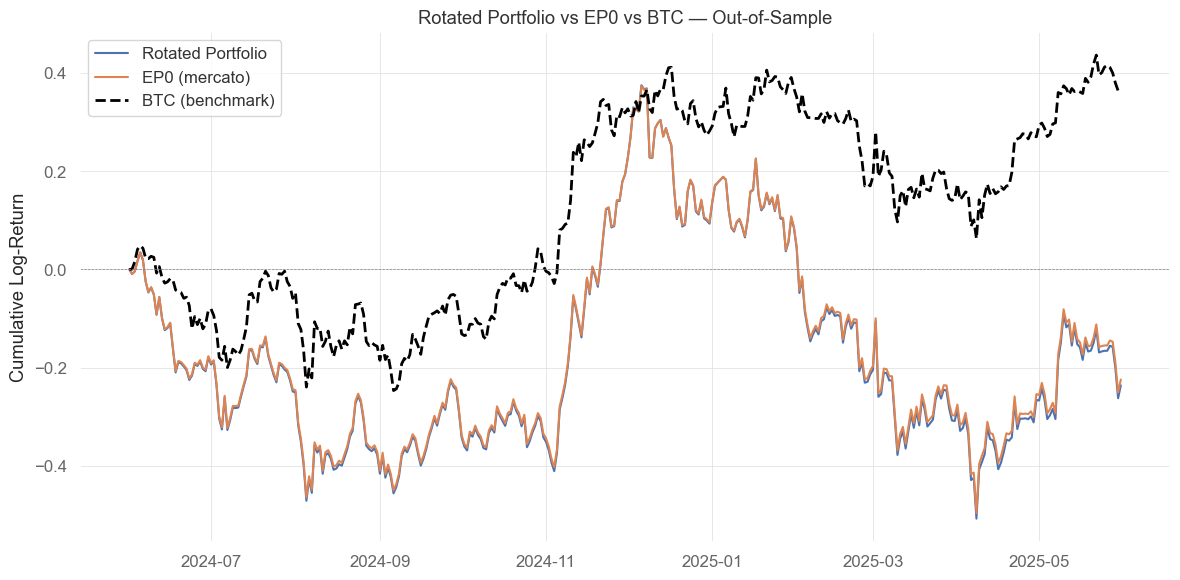


--- Rotated ---
CAGR:          -27.42%
Volatilità:    56.15%
Sharpe:        -0.288
Max Drawdown:  -62.85%

--- EP0 ---
CAGR:          -26.59%
Volatilità:    55.59%
Sharpe:        -0.276
Max Drawdown:  -62.27%


In [48]:
# ── Performance OOS: ruotato vs EP0 vs BTC ───────────────────────────────────
ret_rot = er_oos.fillna(0).dot(w_rot)
ret_ep0_oos = er_oos.fillna(0).dot(pd.Series(w_ep0, index=er_is.columns))

cum_rot     = ret_rot.cumsum()     - ret_rot.cumsum().iloc[0]
cum_ep0_oos = ret_ep0_oos.cumsum() - ret_ep0_oos.cumsum().iloc[0]
cum_btc_iv  = btc_er_oos.reindex(er_oos.index).fillna(0).cumsum()
cum_btc_iv  = cum_btc_iv - cum_btc_iv.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(cum_rot,     linewidth=1.5, label='Rotated Portfolio')
plt.plot(cum_ep0_oos, linewidth=1.5, label='EP0 (mercato)')
plt.plot(cum_btc_iv,  linewidth=2, linestyle='--', color='black', label='BTC (benchmark)')
plt.title('Rotated Portfolio vs EP0 vs BTC — Out-of-Sample')
plt.ylabel('Cumulative Log-Return')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# Tabella performance
for nome, serie in [('Rotated', ret_rot), ('EP0', ret_ep0_oos)]:
    print(f"\n--- {nome} ---")
    print(f"CAGR:          {qs.stats.cagr(serie, periods=252)*100:.2f}%")
    print(f"Volatilità:    {qs.stats.volatility(serie, periods=252)*100:.2f}%")
    print(f"Sharpe:        {qs.stats.sharpe(serie, periods=252):.3f}")
    print(f"Max Drawdown:  {qs.stats.max_drawdown(serie)*100:.2f}%")